In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../data/human_vital_signs_dataset_2024.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (200020, 17)

First 5 rows:
   Patient ID  Heart Rate  Respiratory Rate                   Timestamp  \
0           1          60                12  2024-07-19 21:53:45.729841   
1           2          63                18  2024-07-19 21:52:45.729841   
2           3          63                15  2024-07-19 21:51:45.729841   
3           4          99                16  2024-07-19 21:50:45.729841   
4           5          69                16  2024-07-19 21:49:45.729841   

   Body Temperature  Oxygen Saturation  Systolic Blood Pressure  \
0         36.861707          95.702046                      124   
1         36.511633          96.689413                      126   
2         37.052049          98.508265                      131   
3         36.654748          95.011801                      118   
4         36.975098          98.623792                      138   

   Diastolic Blood Pressure  Age  Gender  Weight (kg)  Height (m)  \
0                        86   37  Female  

In [5]:
label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded: {col}")

# --- Define features and target ---
# Update 'Disease_Risk' to match the actual target column name in your CSV
TARGET = df.columns[-1]   # assumes last column is the target; change if needed
print(f"\nTarget column: {TARGET}")
print("Class distribution:\n", df[TARGET].value_counts())

X = df.drop(columns=[TARGET])
y = df[TARGET]

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Encoded: Timestamp
Encoded: Gender
Encoded: Risk Category

Target column: Risk Category
Class distribution:
 Risk Category
0    105115
1     94905
Name: count, dtype: int64

Train size: 160016 | Test size: 40004


In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42,
        class_weight="balanced"   # handles class imbalance
    ))
])


In [7]:
pipeline.fit(X_train, y_train)
print("\nModel trained successfully!")


Model trained successfully!


In [8]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC (works for binary & multiclass)
n_classes = len(np.unique(y))
if n_classes == 2:
    roc_auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC-AUC Score: {roc_auc:.4f}")
else:
    roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
    print(f"ROC-AUC Score (macro OvR): {roc_auc:.4f}")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
print(f"\n5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Test Accuracy: 0.8177

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.80      0.82     21023
           1       0.79      0.83      0.81     18981

    accuracy                           0.82     40004
   macro avg       0.82      0.82      0.82     40004
weighted avg       0.82      0.82      0.82     40004

ROC-AUC Score: 0.8984

5-Fold CV Accuracy: 0.8199 ± 0.0019


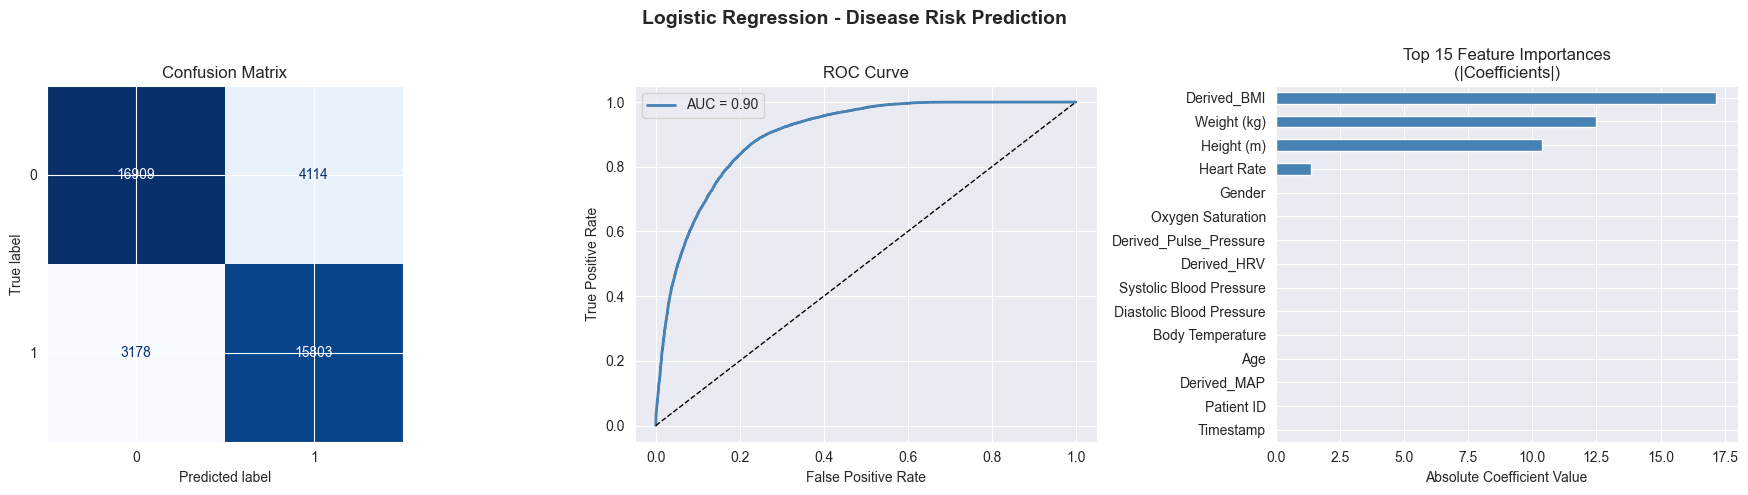


Plot saved as 'logistic_regression_results.png'


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression - Disease Risk Prediction", fontsize=14, fontweight="bold")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# --- ROC Curve (binary only) ---
if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.2f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "ROC Curve\n(Binary only)",
                 ha="center", va="center", fontsize=12)
    axes[1].set_title("ROC Curve")

# --- Feature Importance (Coefficients) ---
model_coefs = pipeline.named_steps["model"].coef_
if model_coefs.shape[0] == 1:
    coefs = model_coefs[0]
else:
    coefs = np.mean(np.abs(model_coefs), axis=0)  # avg across classes

feat_importance = pd.Series(coefs, index=X.columns).abs().sort_values(ascending=False).head(15)
feat_importance.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].invert_yaxis()
axes[2].set_title("Top 15 Feature Importances\n(|Coefficients|)")
axes[2].set_xlabel("Absolute Coefficient Value")

plt.tight_layout()
# plt.savefig("logistic_regression_results.png", dpi=150, bbox_inches="tight")
plt.show()
# print("\nPlot saved as 'logistic_regression_results.png'")

In [10]:
print("\n--- Example: Predict on a new patient ---")
sample = X_test.iloc[[0]]
prediction = pipeline.predict(sample)[0]
probability = pipeline.predict_proba(sample)[0]
print(f"Predicted class : {prediction}")
print(f"Class probabilities: {dict(zip(pipeline.classes_, probability.round(3)))}")


--- Example: Predict on a new patient ---
Predicted class : 1
Class probabilities: {np.int64(0): np.float64(0.036), np.int64(1): np.float64(0.964)}
